In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Detected task type: classification
RandomForest score: 0.9824355971896955
GradientBoost score: 0.9754098360655737
AdaBoost score: 0.9613583138173302
LogisticRegression score: 0.9121779859484778

Best Model: RandomForestClassifier(random_state=42)
Best Score: 0.9824355971896955

Feature Importance:
                    feature  importance
6              cibil_score    0.826375
5                loan_term    0.060163
4              loan_amount    0.029294
8      luxury_assets_value    0.019087
3             income_annum    0.018807
7  commercial_assets_value    0.015468
9         bank_asset_value    0.015137
0         no_of_dependents    0.007602
1                education    0.004079
2            self_employed    0.003987


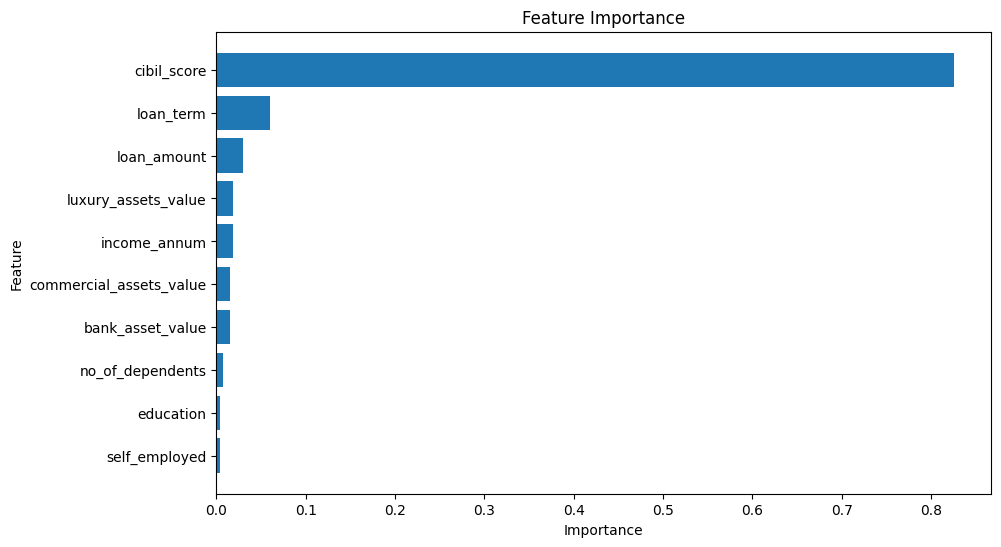

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


# ---------------------- GENERAL PIPELINE ----------------------
class BaseMLPipeline:

    def __init__(self, df, target_column, correlation_threshold=0.95):
        self.df = df.copy()
        self.target_column = target_column
        self.correlation_threshold = correlation_threshold
        self.task_type = None
        self.X = None
        self.y = None
        self.best_model = None
        self.best_score = None
        self.feature_importance_df = None


    # ---------------------- PREPROCESSING ----------------------
    def preprocess(self):

        self.X = self.df.drop(columns=[self.target_column])
        self.y = self.df[self.target_column]

        # Drop id/date columns
        drop_cols = [col for col in self.X.columns if 'id' in col.lower() or 'date' in col.lower()]
        self.X = self.X.drop(columns=drop_cols)

        # Encode categorical
        cat_cols = self.X.select_dtypes(include=['object']).columns.tolist()

        for col in cat_cols:
            le = LabelEncoder()
            self.X[col] = le.fit_transform(self.X[col].astype(str))

        # Fill missing
        for col in self.X.columns:
            if self.X[col].dtype in ['int64','float64']:
                self.X[col] = self.X[col].fillna(self.X[col].median())
            else:
                self.X[col] = self.X[col].fillna(self.X[col].mode()[0])

        # Drop highly correlated features
        if self.X.select_dtypes(include=[np.number]).shape[1] > 1:
            corr_with_target = self.X.corrwith(self.y).abs()
            to_drop = corr_with_target[corr_with_target > self.correlation_threshold].index.tolist()

            if to_drop:
                print("Dropping highly correlated features:", to_drop)
                self.X = self.X.drop(columns=to_drop)


    # ---------------------- TASK DETECTION ----------------------
    def detect_task(self):

        if self.y.nunique() < 10:
            self.task_type = "classification"
        else:
            self.task_type = "regression"

        print("Detected task type:", self.task_type)


    # ---------------------- TRAIN TEST SPLIT ----------------------
    def split_and_balance(self, test_size=0.2):

        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=42
        )

        if self.task_type == "classification":
            smote = SMOTE(random_state=42)
            X_train, y_train = smote.fit_resample(X_train, y_train)

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        return X_train, X_test, y_train, y_test


    # ---------------------- MODEL TRAINING ----------------------
    def train_models(self, X_train, X_test, y_train, y_test):

        if self.task_type == "regression":

            models = {
                "RandomForest": RandomForestRegressor(random_state=42),
                "GradientBoost": GradientBoostingRegressor(random_state=42),
                "AdaBoost": AdaBoostRegressor(random_state=42)
            }

        else:

            models = {
                "RandomForest": RandomForestClassifier(random_state=42),
                "GradientBoost": GradientBoostingClassifier(random_state=42),
                "AdaBoost": AdaBoostClassifier(random_state=42),
                "LogisticRegression": LogisticRegression(max_iter=1000)
            }

        best_score = -np.inf
        best_model = None

        for name, model in models.items():

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            if self.task_type == "regression":
                score = r2_score(y_test, preds)
            else:
                score = accuracy_score(y_test, preds)

            print(name, "score:", score)

            if score > best_score:
                best_score = score
                best_model = model

        self.best_model = best_model
        self.best_score = best_score

        print("\nBest Model:", best_model)
        print("Best Score:", best_score)


    # ---------------------- FEATURE IMPORTANCE ----------------------
    def plot_feature_importance(self):

        if hasattr(self.best_model, "feature_importances_"):

            self.feature_importance_df = pd.DataFrame({
                "feature": self.X.columns,
                "importance": self.best_model.feature_importances_
            }).sort_values(by="importance", ascending=False)

            print("\nFeature Importance:\n", self.feature_importance_df)

            plt.figure(figsize=(10,6))

            plt.barh(
                self.feature_importance_df["feature"],
                self.feature_importance_df["importance"]
            )

            plt.gca().invert_yaxis()
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.title("Feature Importance")

            plt.savefig("feature_importance.png", bbox_inches="tight")
            plt.show()

            self.feature_importance_df.to_csv(
                "feature_importance_report.csv",
                index=False
            )


    # ---------------------- RUN PIPELINE ----------------------
    def run(self):

        self.preprocess()
        self.detect_task()

        X_train, X_test, y_train, y_test = self.split_and_balance()

        self.train_models(X_train, X_test, y_train, y_test)

        self.plot_feature_importance()



# ---------------------- USAGE ----------------------

csv_path = "drive/MyDrive/my_project_ml_fresh/data/loan.csv"

df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

target_column = "loan_status"

df[target_column] = df[target_column].str.strip()

df[target_column] = df[target_column].map({
    "Approved": 1,
    "Rejected": 0
})

pipeline = BaseMLPipeline(df, target_column)

pipeline.run()

In [ ]:
print(df.columns)

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')
